In [1]:
import os
import warnings
import itertools
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import datetime
import time
timestr = time.strftime("%Y%m%d-%H%M%S")
%matplotlib inline
#%pip install ptitprince
import ptitprince as pt
sns.set(style="whitegrid",font_scale=2)


# Exploration

In [2]:
"""from google.colab import drive
drive.mount('/content/drive')
# list files in the folder
print(os.listdir("/content/drive/MyDrive/DMT_data"))"""

'from google.colab import drive\ndrive.mount(\'/content/drive\')\n# list files in the folder\nprint(os.listdir("/content/drive/MyDrive/DMT_data"))'

In [3]:
"""!ln -s "/content/drive/MyDrive/DMT_data" /content/DMT_data
# This should now show your data
!ls /content/DMT_data"""

'!ln -s "/content/drive/MyDrive/DMT_data" /content/DMT_data\n# This should now show your data\n!ls /content/DMT_data'

Plot style

In [4]:
plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e4e4e4",
    "grid.linewidth":    0.05,
    "font.size":         10,
    "axes.titlesize":    11,
    "axes.titleweight":  "bold",
})

BLUE   = "#378ADD"
TEAL   = "#1D9E75"
AMBER  = "#EF9F27"
CORAL  = "#D85A30"
PURPLE = "#7F77DD"
GRAY   = "#888780"

## Read data

In [5]:
data_path = '/content/DMT_data'
data_path = '../data'
train_file = os.path.join(data_path, 'training_set_VU_DM.csv')
test_file = os.path.join(data_path, 'test_set_VU_DM.csv')

train_df = pd.read_csv(train_file)
df = train_df.copy()
display(df.head())
#test = pd.read_csv(test_file)
df.shape

,srch_id,date_time,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
0,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,893,3,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
1,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,10404,4,4.0,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
2,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,21315,3,4.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0
3,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,27348,2,4.0,...,NaN,NaN,NaN,NaN,-1.0,0.0,5.0,0,NaN,0
4,1,2013-04-04 08:32:15,12,187,NaN,NaN,219,29604,4,3.5,...,NaN,NaN,NaN,NaN,0.0,0.0,NaN,0,NaN,0


(4958347, 54)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4958347 entries, 0 to 4958346
Data columns (total 54 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   srch_id                      int64  
 1   date_time                    str    
 2   site_id                      int64  
 3   visitor_location_country_id  int64  
 4   visitor_hist_starrating      float64
 5   visitor_hist_adr_usd         float64
 6   prop_country_id              int64  
 7   prop_id                      int64  
 8   prop_starrating              int64  
 9   prop_review_score            float64
 10  prop_brand_bool              int64  
 11  prop_location_score1         float64
 12  prop_location_score2         float64
 13  prop_log_historical_price    float64
 14  position                     int64  
 15  price_usd                    float64
 16  promotion_flag               int64  
 17  srch_destination_id          int64  
 18  srch_length_of_stay          int64  
 19  srch_bookin

In [7]:
df.describe()

,srch_id,site_id,visitor_location_country_id,visitor_hist_starrating,visitor_hist_adr_usd,prop_country_id,prop_id,prop_starrating,prop_review_score,prop_brand_bool,...,comp6_rate_percent_diff,comp7_rate,comp7_inv,comp7_rate_percent_diff,comp8_rate,comp8_inv,comp8_rate_percent_diff,click_bool,gross_bookings_usd,booking_bool
count,4.958347e+06,4.958347e+06,4.958347e+06,251866.000000,252988.000000,4.958347e+06,4.958347e+06,4.958347e+06,4.950983e+06,4.958347e+06,...,96174.000000,315348.000000,356422.000000,138515.000000,1.916654e+06,1.987503e+06,614730.000000,4.958347e+06,138390.000000,4.958347e+06
mean,1.663666e+05,9.953133e+00,1.753405e+02,3.374334,176.022659,1.739739e+02,7.007918e+04,3.180525e+00,3.777777e+00,6.346994e-01,...,17.250473,0.145969,0.083202,19.433267,-6.089936e-02,9.962752e-03,22.430384,4.474858e-02,386.283316,2.791051e-02
std,9.611223e+04,7.646890e+00,6.591625e+01,0.692519,107.254493,6.834525e+01,4.060992e+04,1.051024e+00,1.050329e+00,4.815144e-01,...,31.160313,0.578202,0.316722,54.370221,4.691723e-01,2.029142e-01,895.965854,2.067514e-01,821.190577,1.647165e-01
min,1.000000e+00,1.000000e+00,1.000000e+00,1.410000,0.000000,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,2.000000,-1.000000,-1.000000,2.000000,-1.000000e+00,-1.000000e+00,2.000000,0.000000e+00,0.000000,0.000000e+00
25%,8.293600e+04,5.000000e+00,1.000000e+02,2.920000,109.810000,1.000000e+02,3.501000e+04,3.000000e+00,3.500000e+00,0.000000e+00,...,6.000000,0.000000,0.000000,7.000000,0.000000e+00,0.000000e+00,7.000000,0.000000e+00,124.000000,0.000000e+00
50%,1.665070e+05,5.000000e+00,2.190000e+02,3.450000,152.240000,2.190000e+02,6.963800e+04,3.000000e+00,4.000000e+00,1.000000e+00,...,11.000000,0.000000,0.000000,12.000000,0.000000e+00,0.000000e+00,11.000000,0.000000e+00,218.400000,0.000000e+00
75%,2.497240e+05,1.400000e+01,2.190000e+02,3.930000,213.490000,2.190000e+02,1.051680e+05,4.000000e+00,4.500000e+00,1.000000e+00,...,18.000000,1.000000,0.000000,20.000000,0.000000e+00,0.000000e+00,17.000000,0.000000e+00,429.790000,0.000000e+00
max,3.327850e+05,3.400000e+01,2.310000e+02,5.000000,1958.700000,2.300000e+02,1.408210e+05,5.000000e+00,5.000000e+00,1.000000e+00,...,1620.000000,1.000000,1.000000,9900.000000,1.000000e+00,1.000000e+00,149400.000000,1.000000e+00,159292.380000,1.000000e+00


In [8]:
print("Unique users:", df["srch_id"].nunique())

Unique users: 199795


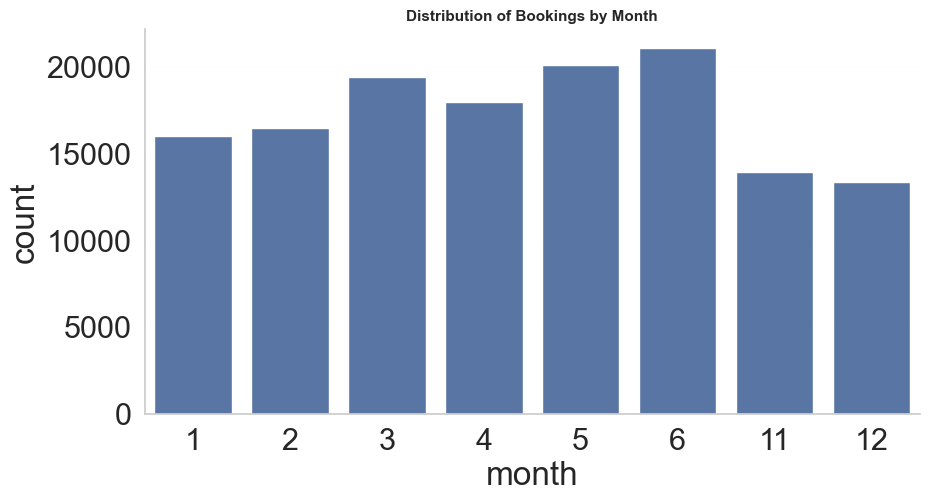

In [9]:
def get_datetime(data):
    df['date_time'] = pd.to_datetime(df['date_time'])
    data['month'] = data['date_time'].dt.month
    data['day_of_week'] = data['date_time'].dt.dayofweek
    data['hour'] = data['date_time'].dt.hour
    return data

df = get_datetime(df)

# booking distribution by month
plt.figure(figsize=(10, 5))
sns.countplot(data=df[df['booking_bool'] == 1], x='month')
plt.title('Distribution of Bookings by Month')
plt.show()

Interpretation: interestingly in the training data we do not have any bookings from July-October. Probably they split the data November-June -> training, and July-October -> test

### Nulls

In [10]:
#df.columns.tolist()
df.isnull().sum()

srch_id                              0
date_time                            0
site_id                              0
visitor_location_country_id          0
visitor_hist_starrating        4706481
visitor_hist_adr_usd           4705359
prop_country_id                      0
prop_id                              0
prop_starrating                      0
prop_review_score                 7364
prop_brand_bool                      0
prop_location_score1                 0
prop_location_score2           1090348
prop_log_historical_price            0
position                             0
price_usd                            0
promotion_flag                       0
srch_destination_id                  0
srch_length_of_stay                  0
srch_booking_window                  0
srch_adults_count                    0
srch_children_count                  0
srch_room_count                      0
srch_saturday_night_bool             0
srch_query_affinity_score      4640941
orig_destination_distance

In [11]:
# % of missing values per column
missing_col_pct = (df.isnull().sum() / len(df)) * 100

# descending order sort
missing_col_pct = missing_col_pct.sort_values(ascending=False)

# only columns with some missing data
display(missing_col_pct[missing_col_pct > 0])

comp1_rate_percent_diff      98.095353
comp6_rate_percent_diff      98.060362
comp1_rate                   97.581250
comp1_inv                    97.387053
comp4_rate_percent_diff      97.356256
gross_bookings_usd           97.208949
comp7_rate_percent_diff      97.206428
comp6_rate                   95.156511
visitor_hist_starrating      94.920364
visitor_hist_adr_usd         94.897735
comp6_inv                    94.736633
comp4_rate                   93.800797
comp7_rate                   93.640058
srch_query_affinity_score    93.598552
comp4_inv                    93.069001
comp7_inv                    92.811677
comp3_rate_percent_diff      90.464625
comp2_rate_percent_diff      88.781786
comp8_rate_percent_diff      87.602118
comp5_rate_percent_diff      83.036706
comp3_rate                   69.056462
comp3_inv                    66.702814
comp8_rate                   61.344900
comp8_inv                    59.916016
comp2_rate                   59.166392
comp2_inv                

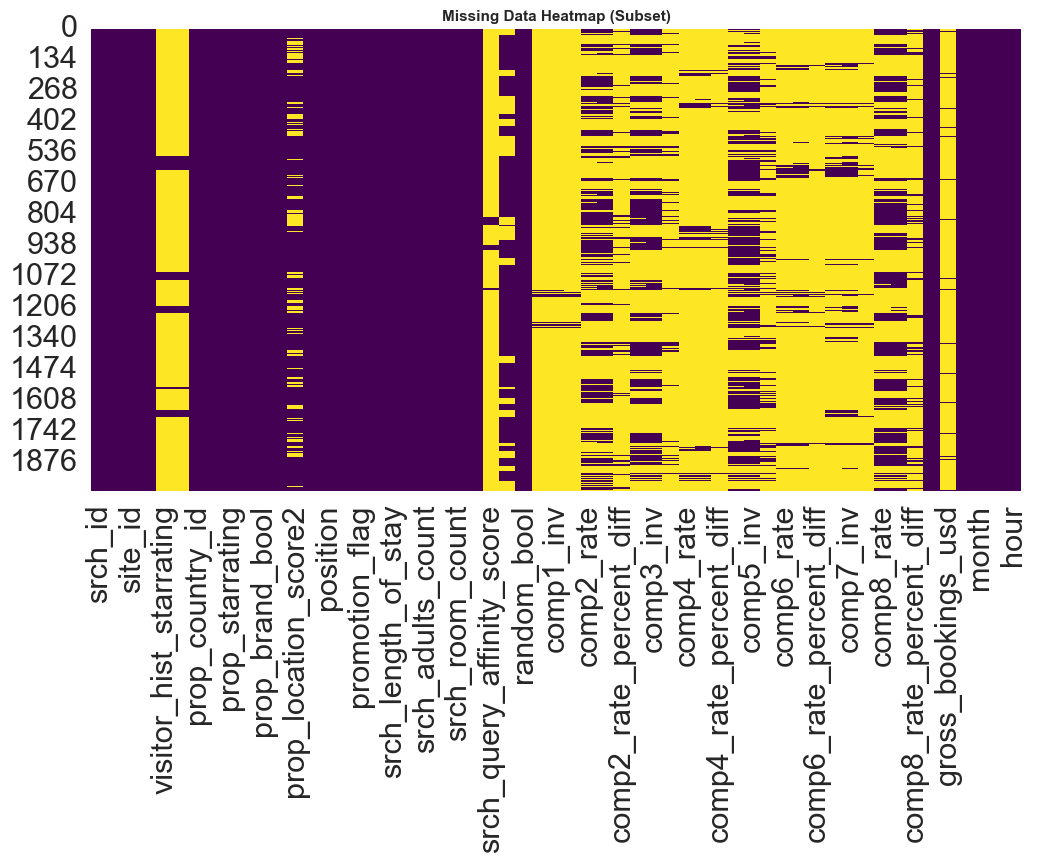

In [12]:
# visualise the first 2000 rows to see if there is any clustering in the missing data
plt.figure(figsize=(12, 6))
sns.heatmap(df.iloc[:2000].isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap (Subset)")
plt.show()

interpretation: yellow is missing data, purple is where data is present. Where both columns are yellow - both feautres are not present.

In [13]:
# check if gross_bookings_usd is missing when booking_bool is 0
missing_logic = df.groupby('booking_bool')['gross_bookings_usd'].apply(lambda x: x.isnull().mean() * 100)
print(f"Percentage of missing 'gross_bookings_usd' by 'booking_bool':\n{missing_logic}")
print("---")


Percentage of missing 'gross_bookings_usd' by 'booking_bool':
booking_bool
0    100.0
1      0.0
Name: gross_bookings_usd, dtype: float64
---


Interpretation: gross_bookings_usd - a 1:1 correlation: gross_bookings_usd is always missing when booking_bool is 0 (when the booking was not made)
Q: should we drop it?

In [14]:
# check how many competitor columns have data per row
comp_rate_cols = [c for c in df.columns if 'rate' in c and 'comp' in c]
df['comp_data_count'] = df[comp_rate_cols].notnull().sum(axis=1)
print(df['comp_data_count'].value_counts(normalize=True).sort_index())

comp_data_count
0     3.462460e-01
1     7.305943e-02
2     1.286066e-01
3     1.444814e-01
4     1.432661e-01
5     5.926552e-02
6     5.984313e-02
7     1.687942e-02
8     2.440188e-02
9     1.307694e-03
10    2.058347e-03
11    1.968398e-04
12    3.872258e-04
13    4.033602e-07
Name: proportion, dtype: float64


Interpretation: 34% of listings do not have any competitor data

In [15]:
# check if prop_review_score missingness correlates with position
# i.e. does a lack of reviews lead to lower search placement?
print(df.groupby(df['prop_review_score'].isnull())['position'].mean())

prop_review_score
False    16.854939
True     17.728544
Name: position, dtype: float64


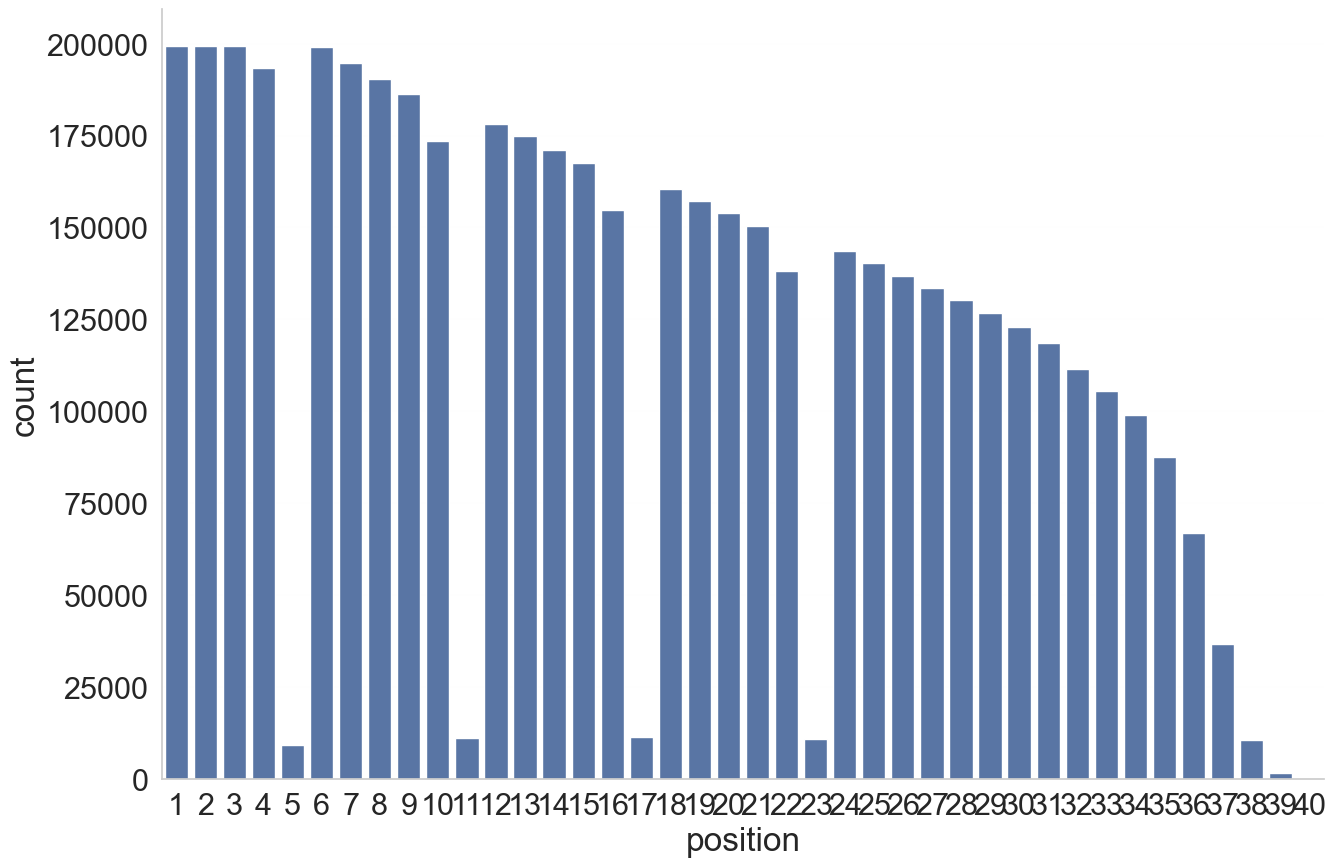

In [16]:
# search position distribution
plt.figure(figsize=(15,10))
sns.countplot(data=df, x='position')
plt.show()

Interpretaiton: this shows little difference, however the logic assumes that all searched have around 35 resutls. VS. more meaningful would be analysing waht is the relative position of the property in the search and how does that compare with the review_score. So we check for relative ranks:

In [17]:

# calculate relative position per search session
df['rel_position'] = df.groupby('srch_id')['position'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min()) if (x.max() - x.min()) != 0 else 0
)

# compare the means
comparison = df.groupby(df['prop_review_score'].isnull())['rel_position'].mean()
print("Mean Relative Position (0 = Top, 1 = Bottom):")
print(comparison)

# checking the significance - delta
delta = comparison[True] - comparison[False]
print(f"\nRanking Penalty for Missing Reviews: {delta:.4f}")

Mean Relative Position (0 = Top, 1 = Bottom):
prop_review_score
False    0.510327
True     0.622771
Name: rel_position, dtype: float64

Ranking Penalty for Missing Reviews: 0.1124


Interpretation: properties without a review score are, on average, ranked 11.24% lower in search results than those with reviews.
Q: should we do anything about this?

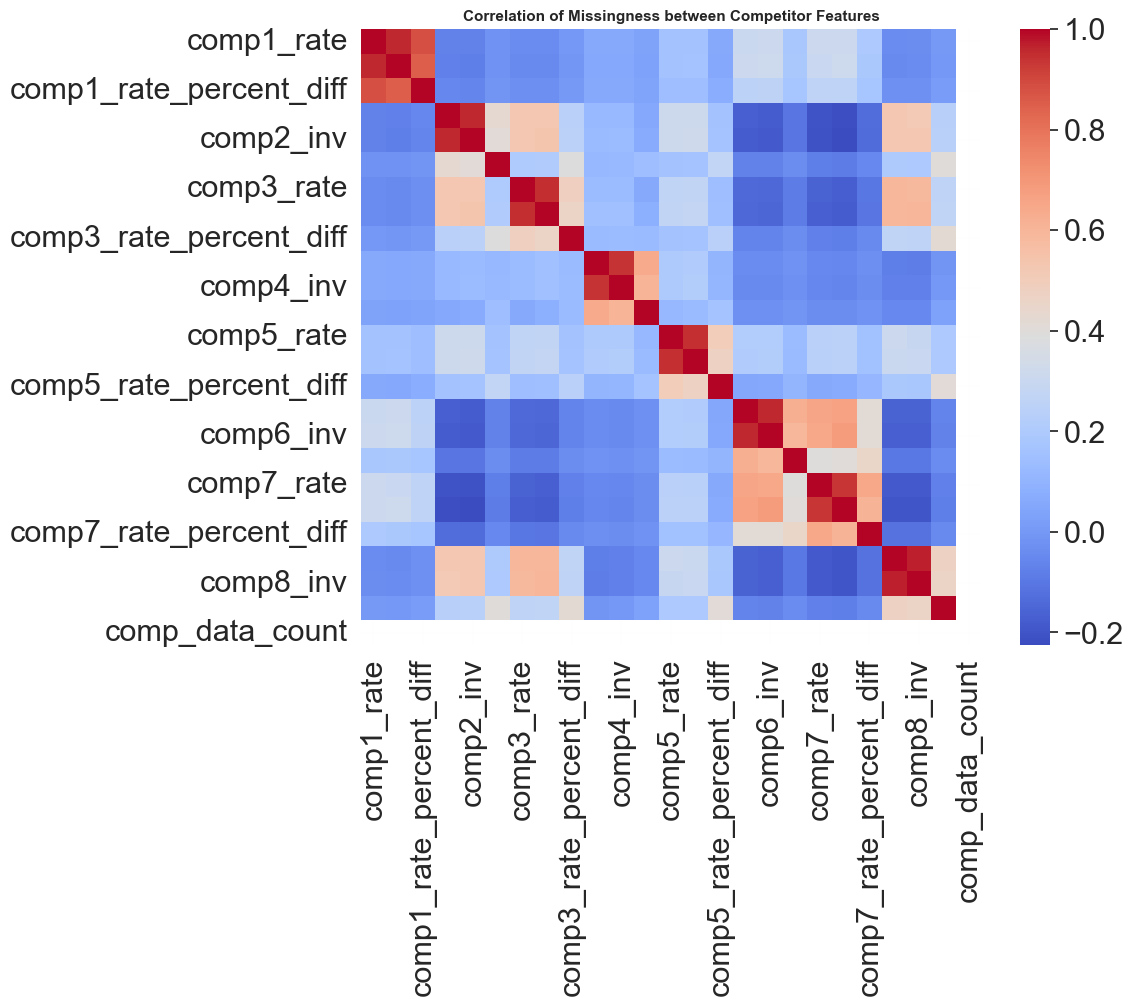

In [18]:
# check if competitor columns are missing simultaneously
comp_cols = [c for c in df.columns if 'comp' in c]
plt.figure(figsize=(10, 8))
sns.heatmap(df[comp_cols].isnull().corr(), annot=False, cmap='coolwarm')
plt.title("Correlation of Missingness between Competitor Features")
plt.show()

Interpretation: competitor columns mostly are missing within a comeptitor themsleves- there is some higher correlation between competior 2&3 and 6 & 7. 

### Descriptive statistics

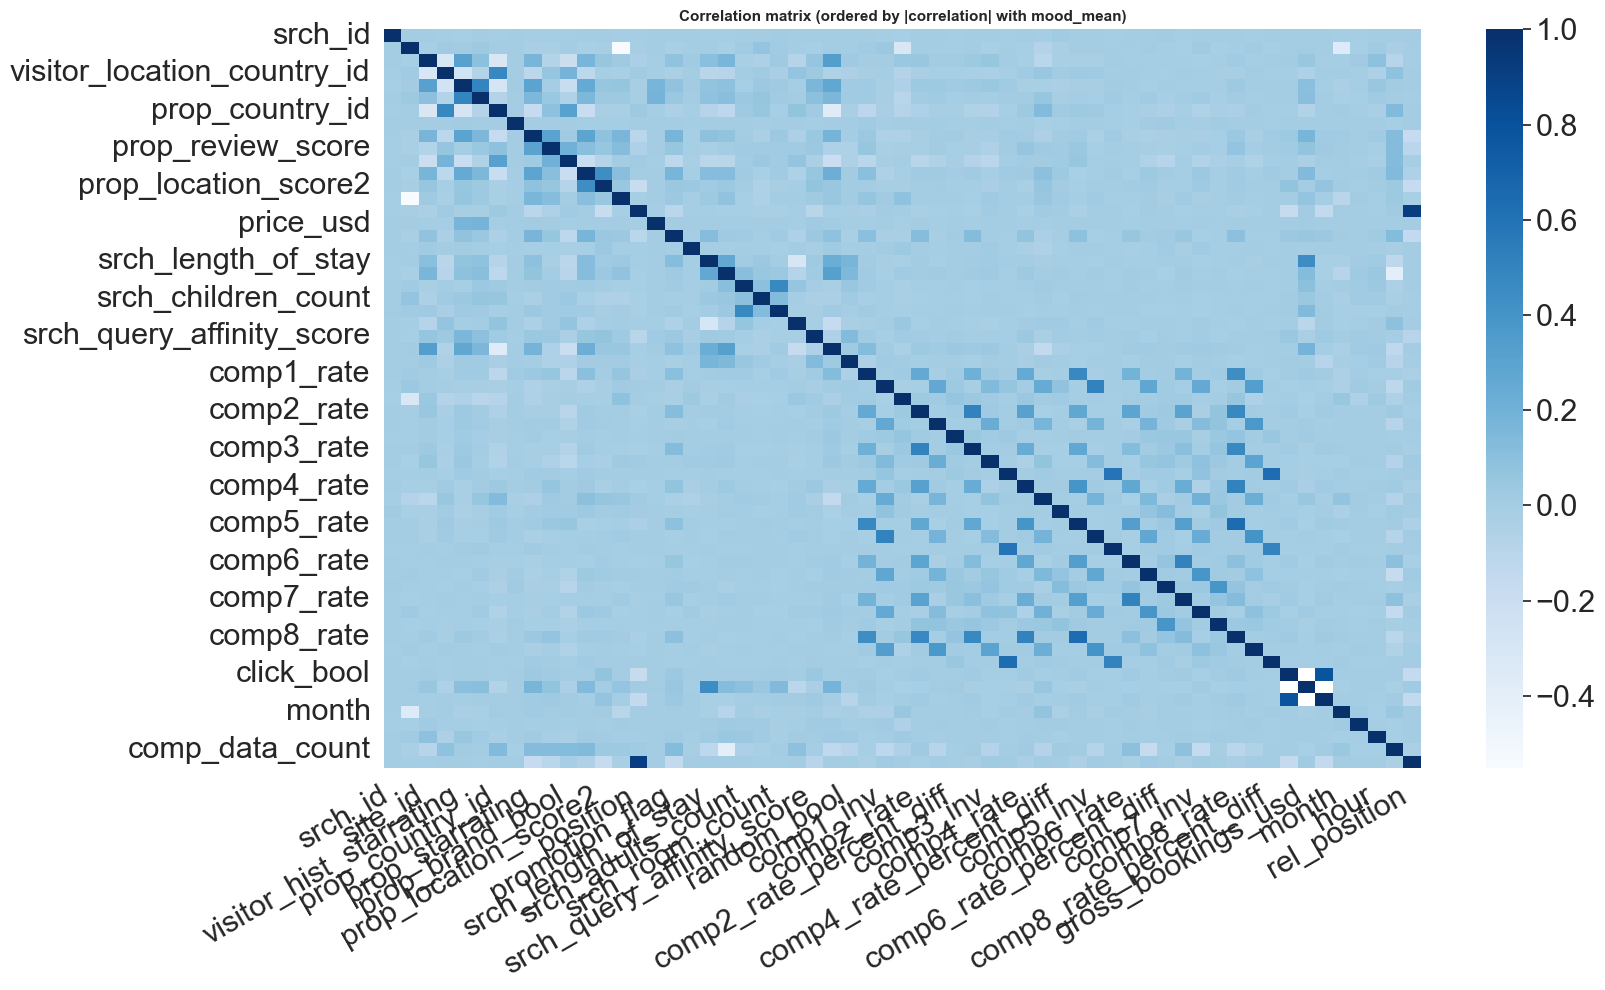

In [19]:
# correlation between features
corr = df.corr()
fig, ax = plt.subplots(figsize=(17, 10))
sns.heatmap(corr, cmap='Blues', ax=ax)
ax.set_title("Correlation matrix (ordered by |correlation| with mood_mean)")
ax.set_xticklabels(ax.get_xticklabels(),rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../figures/train_correlation_matrix.png", dpi=150)
plt.show()

In [20]:
#time.sleep(60)
numeric_cols = df.select_dtypes(include=[np.number]).columns #numeric columns

# calculate basic stats
stats = df[numeric_cols].describe().T

# calculate missing values
stats["missing"] = df[numeric_cols].isnull().sum()
stats["missing %"] = (stats["missing"] / len(df) * 100).round(1)
stats = stats.sort_values("missing %", ascending=False) # sort by missing %
display(stats)

,count,mean,std,min,25%,50%,75%,max,missing,missing %
comp1_rate_percent_diff,94439.0,244.229916,1165.448634,2.0000,7.000000,10.000000,16.000000,3.038900e+04,4863908,98.1
comp6_rate_percent_diff,96174.0,17.250473,31.160313,2.0000,6.000000,11.000000,18.000000,1.620000e+03,4862173,98.1
comp1_rate,119930.0,0.479788,0.641565,-1.0000,0.000000,1.000000,1.000000,1.000000e+00,4838417,97.6
comp1_inv,129559.0,0.031059,0.229688,-1.0000,0.000000,0.000000,0.000000,1.000000e+00,4828788,97.4
comp4_rate_percent_diff,131086.0,175.316533,5757.739837,2.0000,7.000000,11.000000,19.000000,1.001584e+06,4827261,97.4
comp7_rate_percent_diff,138515.0,19.433267,54.370221,2.0000,7.000000,12.000000,20.000000,9.900000e+03,4819832,97.2
gross_bookings_usd,138390.0,386.283316,821.190577,0.0000,124.000000,218.400000,429.790000,1.592924e+05,4819957,97.2
comp6_rate,240157.0,0.128329,0.559841,-1.0000,0.000000,0.000000,0.000000,1.000000e+00,4718190,95.2
visitor_hist_starrating,251866.0,3.374334,0.692519,1.4100,2.920000,3.450000,3.930000,5.000000e+00,4706481,94.9
visitor_hist_adr_usd,252988.0,176.022659,107.254493,0.0000,109.810000,152.240000,213.490000,1.958700e+03,4705359,94.9


## More plots

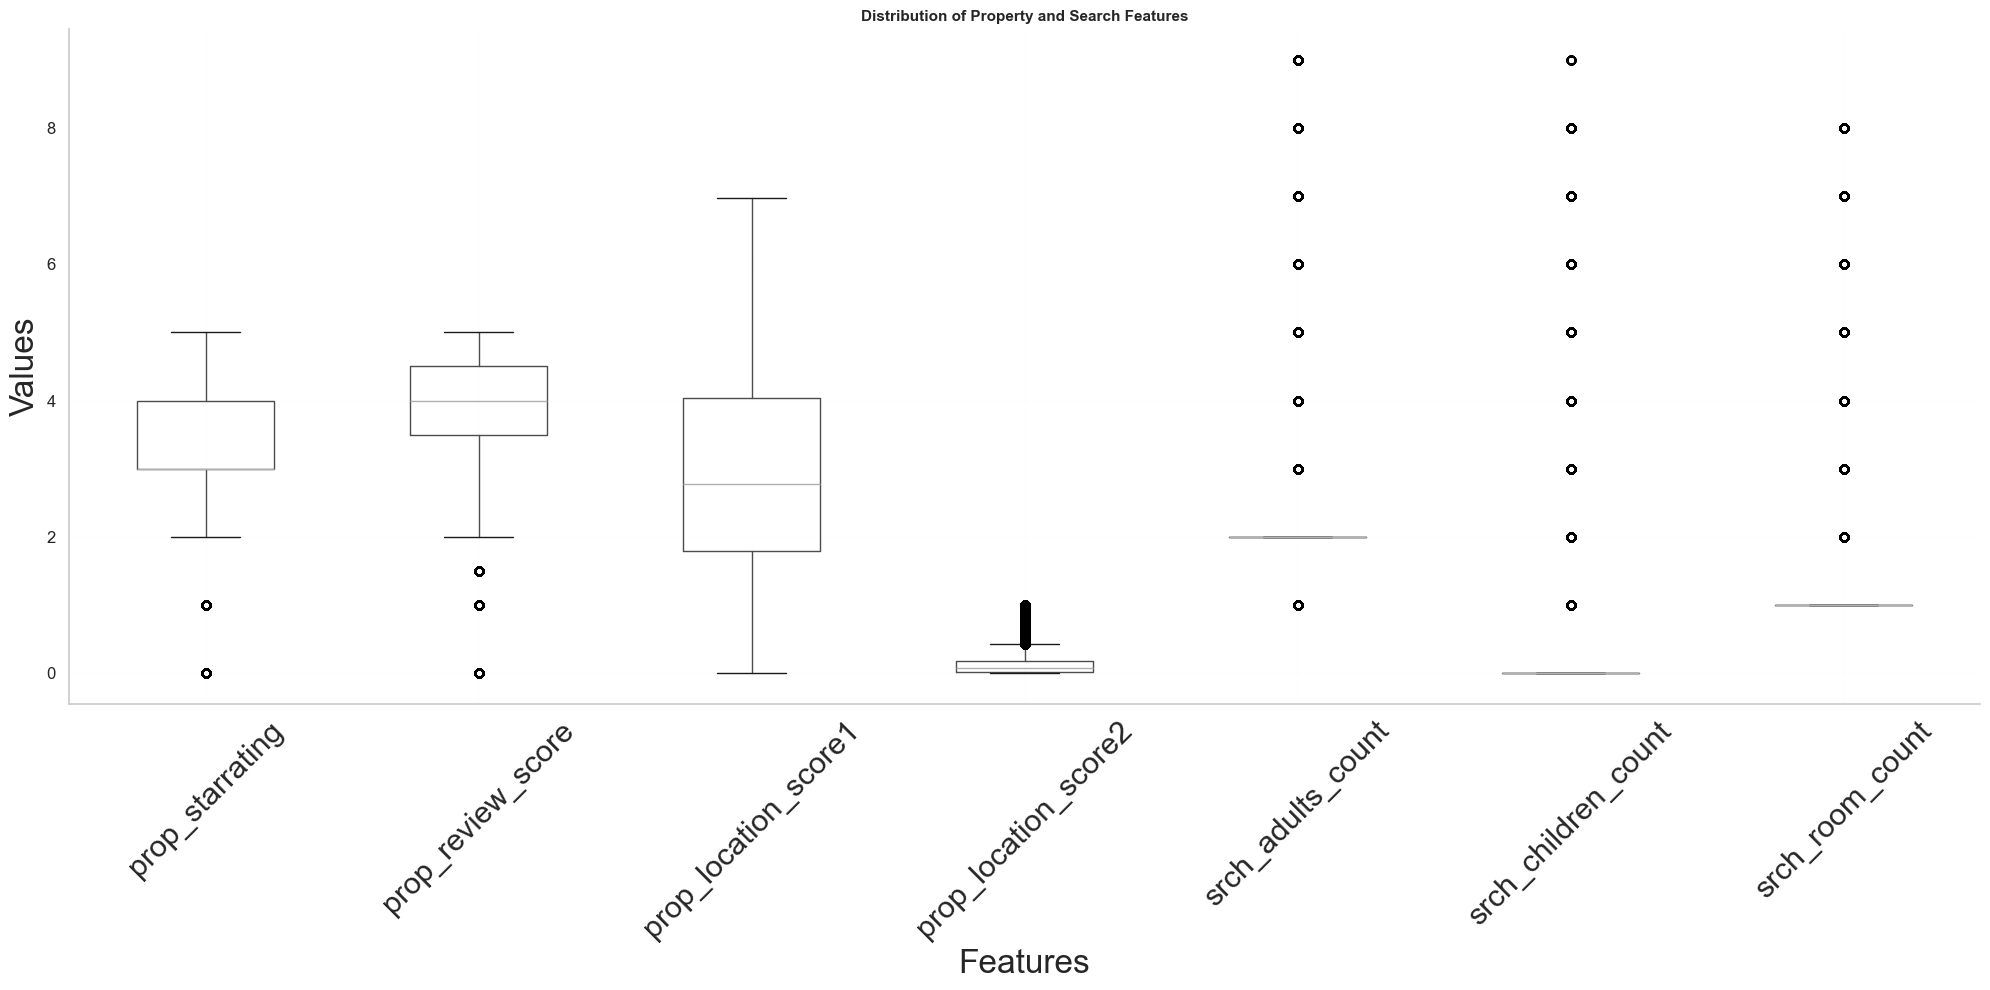

In [21]:
numerical_cols = ['prop_starrating', 'prop_review_score', 'prop_location_score1','prop_location_score2', 'srch_adults_count', 'srch_children_count', 'srch_room_count']

plt.figure(figsize=(20, 10))
df.boxplot(column=numerical_cols)
plt.title("Distribution of Property and Search Features")
plt.xticks(rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Features")
plt.ylabel("Values")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

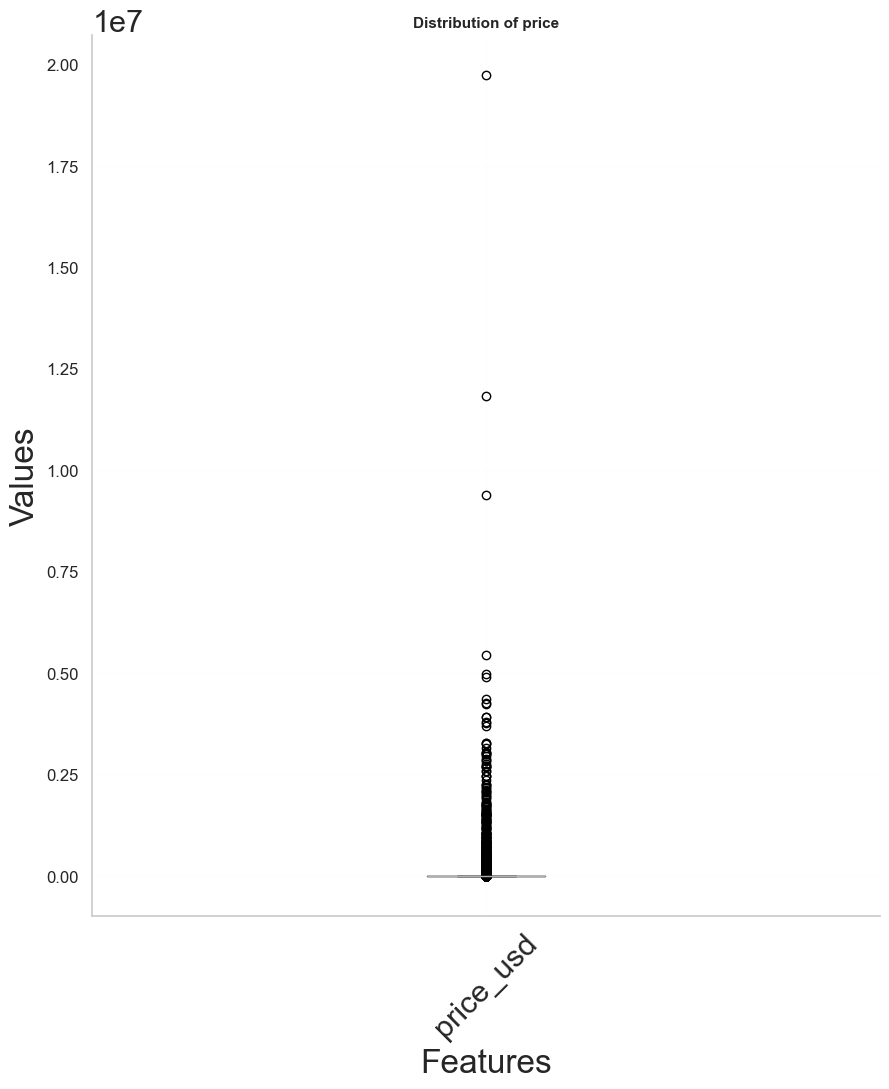

In [22]:
plt.figure(figsize=(9, 11))
df.boxplot(column='price_usd')
plt.title("Distribution of price")
plt.xticks(rotation=45)
plt.yticks(fontsize=12)
plt.xlabel("Features")
plt.ylabel("Values")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Intepretation: we see that price has many outliers and is on a totally different scale than other variables from the preivous plot - Q: since we do scaling later, do we need to do anythig else about this?

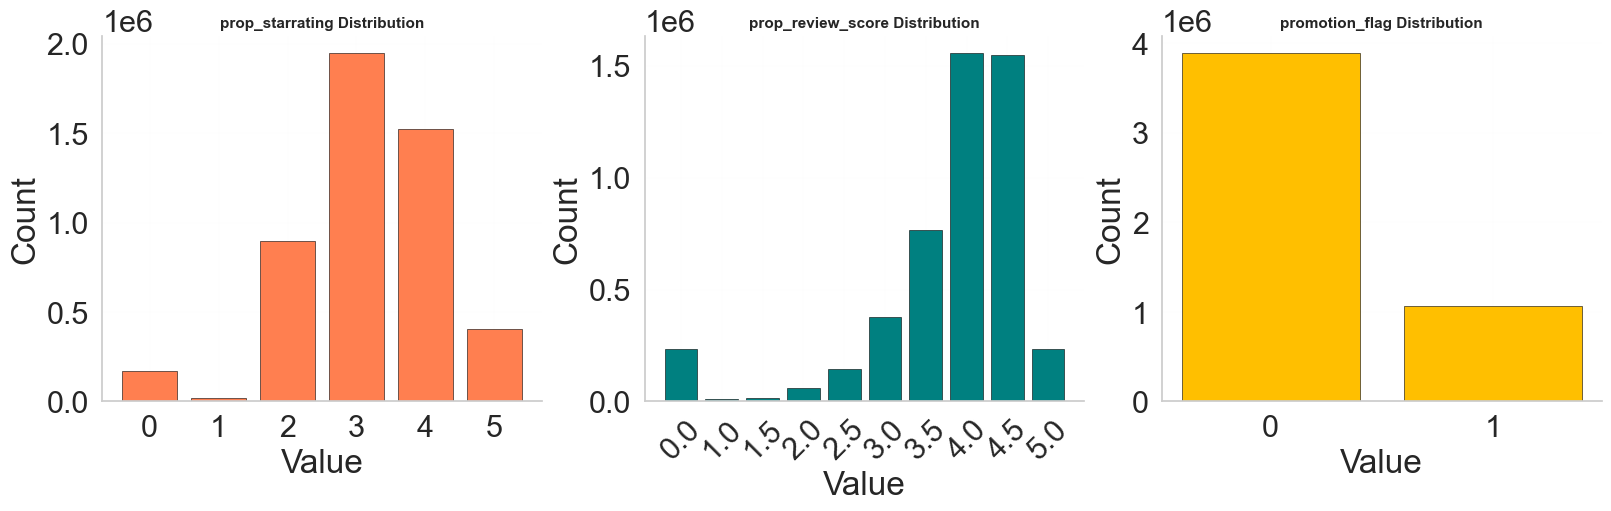

In [23]:
# plotting key variables identified from literature
important_vars = ["prop_starrating", "prop_review_score", "promotion_flag"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

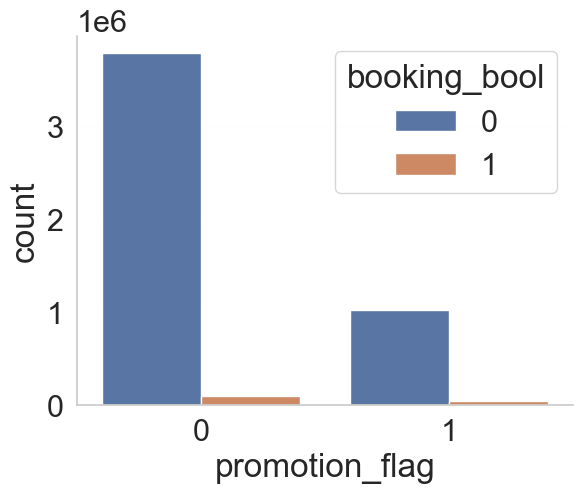

In [24]:
# booking based on the promotion flag
sns.countplot(data=df, x='promotion_flag', hue='booking_bool')
plt.show()

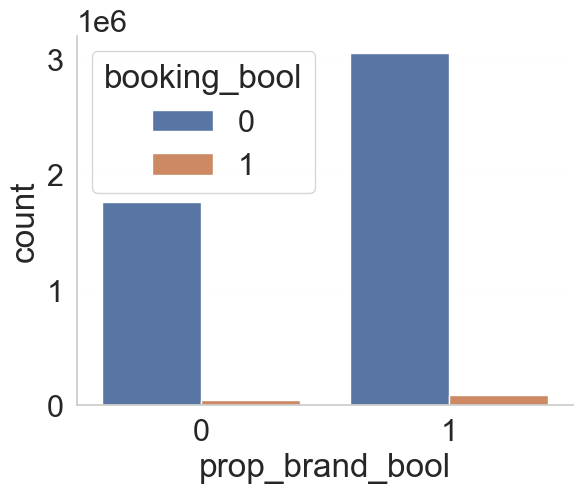

In [25]:
# distribution of booking based on the chain/independent bool
sns.countplot(data=df, x='prop_brand_bool', hue='booking_bool')
plt.show()

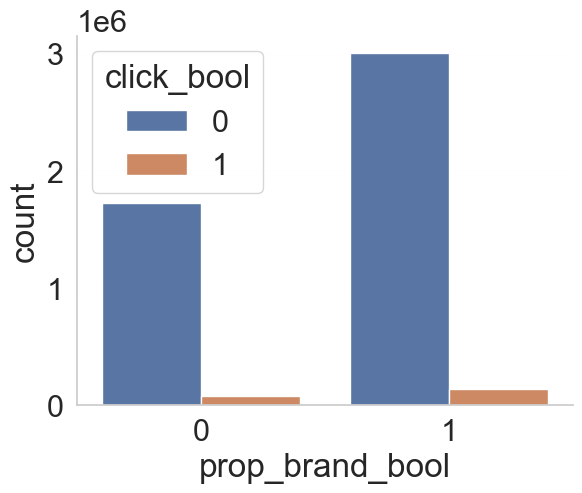

In [26]:
# distribution of clicks based on the chain/independent bool
sns.countplot(data=df, x='prop_brand_bool', hue='click_bool')
plt.show()

## target variables

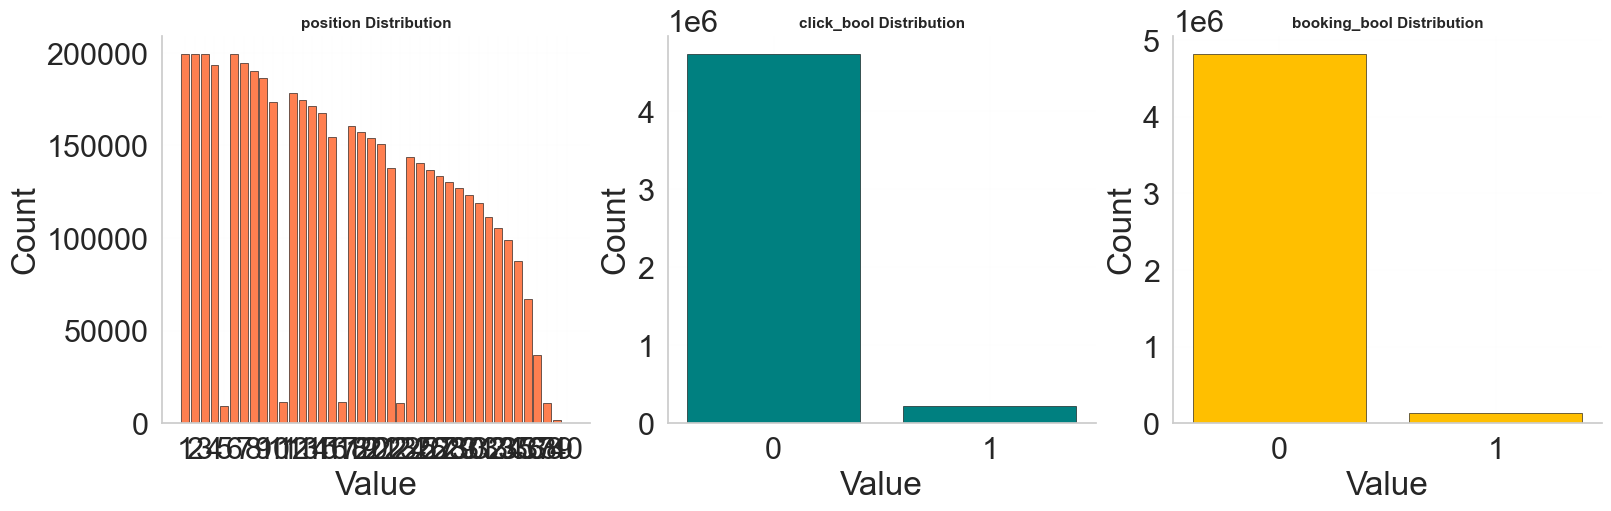

In [27]:

# plotting key variables
important_vars = ["position", "click_bool", "booking_bool"]
colors = ['#FF7F50', '#008080', '#FFBF00']

fig, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

for ax, var, color in zip(axes, important_vars, colors):
    # drop NA for plotting
    vals = df[var].dropna()

    # use value_counts for discrete/categorical-like numeric data
    counts = vals.value_counts().sort_index()

    ax.bar(counts.index.astype(str), counts.values,
           color=color, edgecolor="black", linewidth=0.4)

    ax.set_title(f"{var} Distribution")
    ax.set_xlabel("Value")
    ax.set_ylabel("Count")

    # handle overlapping x-labels for review scores
    if var == "prop_review_score":
        ax.tick_params(axis="x", rotation=45)

plt.show()

Interpretation: this shows that the data is imbalanced for the booking_bool

## Other variables

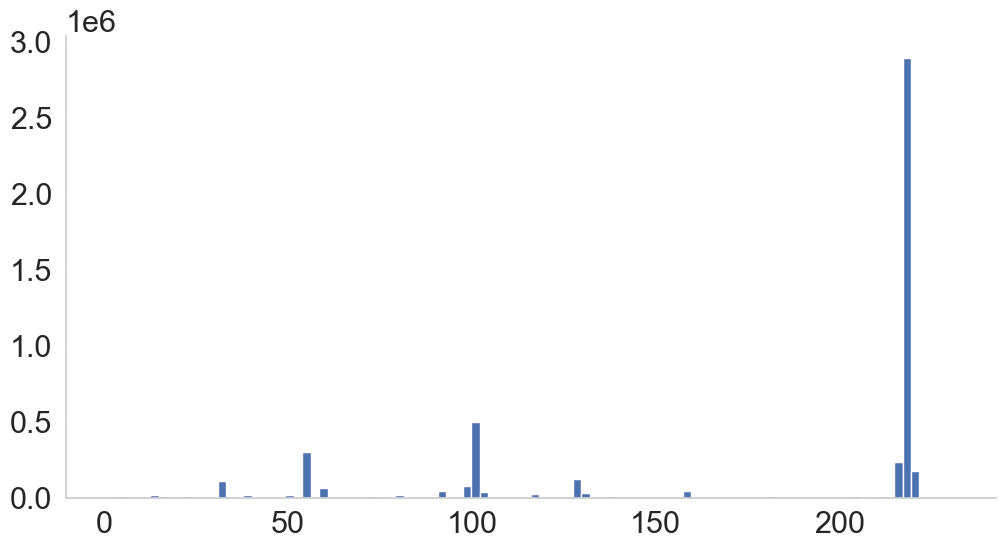

In [28]:
plt.figure(figsize=(12, 6))
plt.hist(df['visitor_location_country_id'], bins =100)
plt.show()

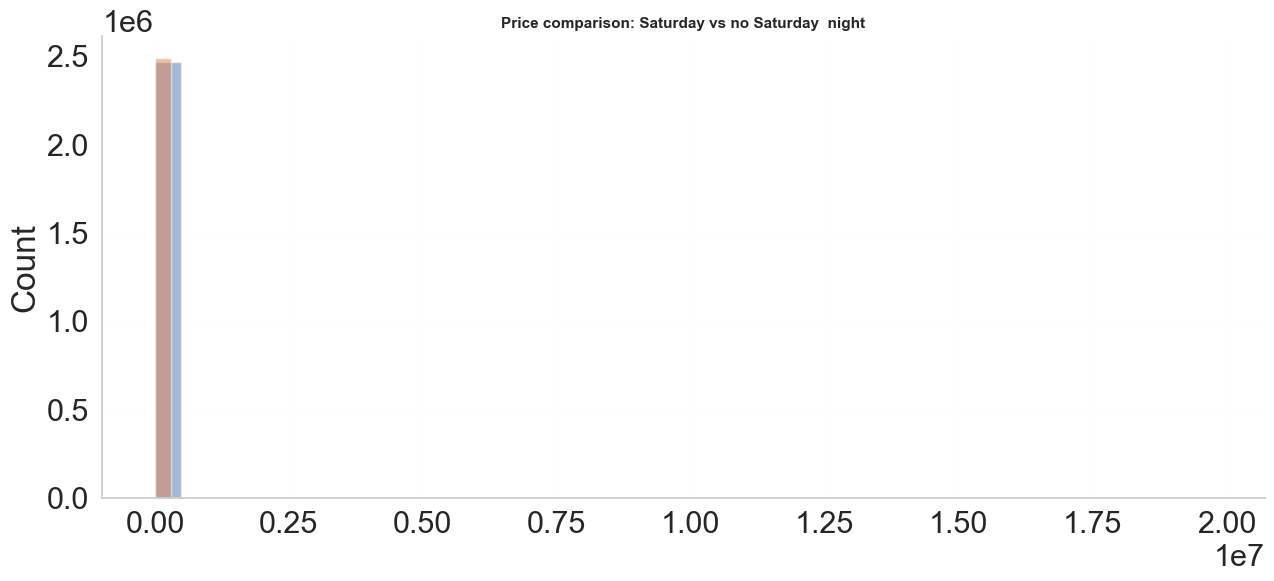

In [29]:
non_saturday = df.loc[df['srch_saturday_night_bool'] == 0, 'price_usd']
saturday = df.loc[df['srch_saturday_night_bool'] == 1, 'price_usd']

plt.figure(figsize=(15, 6))
plt.hist(non_saturday, bins = 40, alpha=0.5, label='Search  no Saturday night')
plt.hist(saturday, bins = 40, alpha=0.5, label='Search Saturday night')
plt.ylabel('Count')
plt.title("Price comparison: Saturday vs no Saturday  night")
plt.show()

#Price is more stable and lower when searching Non-Saturday night and price goes up when searching Saturday night

### Promotion flag

In [30]:
# checking how the promotion flag correlates with the average position
promotion_stats = df.groupby('promotion_flag')['position'].mean().reset_index()

promotion_stats.columns = ['Promotion Flag', 'Average Position']
print(promotion_stats)

   Promotion Flag  Average Position
0               0         17.422649
1               1         14.795745


We see that the promotion flag means the average position is higher

In [31]:
# BIAS: we use Independent Samples T-Test to check if this difference is statistically significant - if algorithm promotes discounted hotels
from scipy import stats

# separate data into two groups
group_no_promo = df[df['promotion_flag'] == 0]['position']
group_promo = df[df['promotion_flag'] == 1]['position']

#Welch's T-test
t_stat, p_value = stats.ttest_ind(group_no_promo, group_promo, equal_var=False)
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# interpretation
alpha = 0.05
if p_value < alpha:
    print("The difference is statistically significant (Reject H0).")
else:
    print("The difference is not statistically significant (Fail to reject H0).")


T-statistic: 230.9399
P-value: 0.0000e+00
The difference is statistically significant (Reject H0).


Since the dataset is very large, even small differences result in a statistically significant result, as in here. we should mention that while statistically significant, the practical significance (the ~2.6 rank jump) is what truly influences the user's likelihood to click or book.

# Data cleaning

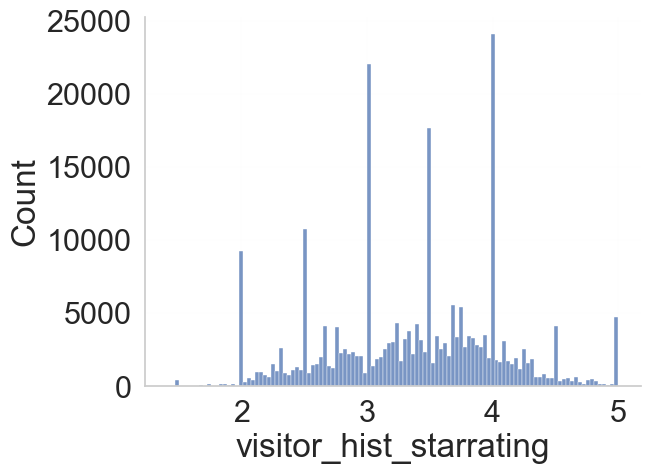

In [32]:
# we saw that the historical starring is missing for 94%
sns.histplot(data = df, x= 'visitor_hist_starrating')
plt.show()

https://wellcomeopenresearch.org/articles/4-63/v2

https://github.com/RainCloudPlots/RainCloudPlots/blob/master/manuscript_code/figure4.ipynb for the cloud plots 

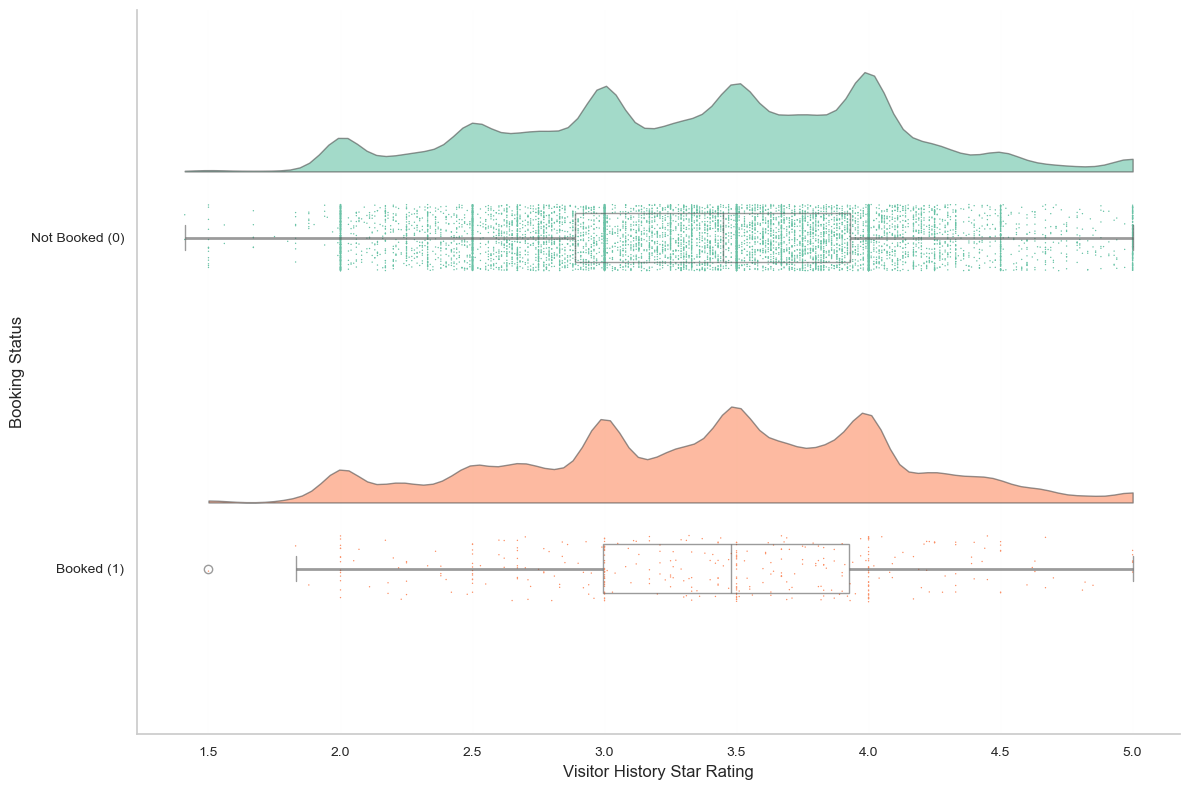

In [33]:
#subset of the data - drop NaNs first, then sample 5,000 rows for visual clarity
plot_df = df[['visitor_hist_starrating', 'booking_bool']].dropna()
plot_df = plot_df.sample(n=10000, random_state=42) 

# figure
fig, ax = plt.subplots(figsize=(12, 8))
ax = pt.RainCloud(
    data=plot_df, 
    x="booking_bool", # x = Categorical (Group)
    y="visitor_hist_starrating", #y = Numerical (Value)
    orient='h',
    bw=.1,
    width_viol=.6, # half-violin width
    ax=ax,
    palette="Set2",
    alpha=0.6, # transparency
    #dodge=True,
    point_size=1  
)

sns.despine()
ax.set_yticklabels(['Not Booked (0)', 'Booked (1)'], fontsize = 10)
ax.tick_params(axis='x', labelsize=10)
ax.set_xlabel("Visitor History Star Rating", fontsize = 12)
ax.set_ylabel("Booking Status", fontsize = 12)

# save
plt.tight_layout()
fig.savefig('../figures/figure_expedia_raincloud.jpg', dpi=300)
plt.show()

In [34]:
# calculate metrics and drop nans in the dfs
rating_mean = df['visitor_hist_starrating'].mean()
rating_median = df['visitor_hist_starrating'].median()
rating_trimmed = stats.trim_mean(df['visitor_hist_starrating'].dropna(), 0.1)

# results
print("Runtime Minutes Statistics:")
print(f"Min: {df['visitor_hist_starrating'].min()}")
print(f"Max: {df['visitor_hist_starrating'].max()}")
print(fr"Median: {rating_median:.2f}")
print(fr"Mean: {rating_mean:.2f}")
print(fr"5% Trimmed Mean: {rating_trimmed:.2f}")

Runtime Minutes Statistics:
Min: 1.41
Max: 5.0
Median: 3.45
Mean: 3.37
5% Trimmed Mean: 3.38


and we see that it is more or less similarly disitrbuted for booked and not booked. also the mean and 10% trimmed mean are almost identical, but the median is a little higher -  so we impute with the k-trimmed mean as it;s usaully more robust to outliers.

In [35]:
# apply the 10% trimmed mean to visitor_hist_starrating
df['visitor_hist_starrating'] = df['visitor_hist_starrating'].fillna(rating_trimmed)

### competitor data
I'm dropping the rest of the competitior data for now - - there is many missing columns. for now I created binary flags 

In [36]:
# competitor rate columns
rate_cols = [f'comp{i}_rate' for i in range(1, 9)]
diff_cols = [f'comp{i}_rate_percent_diff' for i in range(1, 9)]

# 1. comp_score_sum: Sum of rates (-1,0,1)
df['comp_score_sum'] = df[rate_cols].sum(axis=1, skipna=True)

# 2. binary flag - is expedia cheaper / more expensive than any competitor
df['is_cheapest_any'] = (df[rate_cols] == 1).any(axis=1).astype(int)
df['is_expensive_any'] = (df[rate_cols] == -1).any(axis=1).astype(int)


#this currently is very skewed but we can explore sth with the competitive advantage
"""
# 3. average price difference where data exists - we need to add a sign first
signed_diffs = pd.DataFrame()
for i in range(1, 9):
    signed_diffs[f'signed_{i}'] = df[f'comp{i}_rate'] * df[f'comp{i}_rate_percent_diff']

df['comp_avg_signed_diff'] = signed_diffs.mean(axis=1, skipna=True).fillna(0)
"""

"\n# 3. average price difference where data exists - we need to add a sign first\nsigned_diffs = pd.DataFrame()\nfor i in range(1, 9):\n    signed_diffs[f'signed_{i}'] = df[f'comp{i}_rate'] * df[f'comp{i}_rate_percent_diff']\n\ndf['comp_avg_signed_diff'] = signed_diffs.mean(axis=1, skipna=True).fillna(0)\n"

In [ ]:
# baseline booking rate - global mean
baseline = df['booking_bool'].mean()

plt.figure(figsize=(7, 6))
ax = sns.barplot(data=df, x='is_cheapest_any', y='booking_bool', palette='RdYlGn')
plt.axhline(baseline, color='red', linestyle='--', label=f'Global Baseline ({baseline:.2%})')

plt.title("Impact of Being the Cheapest Competitor on Booking Rate")
plt.ylabel("Mean Booking Rate")
plt.xlabel("Is Expedia the Cheapest? (0=No, 1=Yes)")
plt.legend(loc='upper right')
plt.show()

In [38]:
# drop the rest of competitor data- contains more a lot of missing values
features = ['comp1_rate', "comp1_inv", "comp1_rate_percent_diff",
            'comp2_rate', "comp2_inv", "comp2_rate_percent_diff",
            'comp3_rate', "comp3_inv", "comp3_rate_percent_diff",
            'comp4_rate', "comp4_inv", "comp4_rate_percent_diff",
            'comp5_rate', "comp5_inv", "comp5_rate_percent_diff",
            'comp6_rate', "comp6_inv", "comp6_rate_percent_diff",
            'comp7_rate', "comp7_inv", "comp7_rate_percent_diff",
            'comp8_rate', "comp8_inv", "comp8_rate_percent_diff"]
df.drop(columns = features, inplace=True)

In [39]:
#check what columns are still missing data
missing_col_pct = (df.isnull().sum() / len(df)) * 100 # % of missing values per column
missing_col_pct = missing_col_pct.sort_values(ascending=False) # descending order sort
display(missing_col_pct[missing_col_pct > 0]) # only columns with some missing data

gross_bookings_usd           97.208949
visitor_hist_adr_usd         94.897735
srch_query_affinity_score    93.598552
orig_destination_distance    32.425766
prop_location_score2         21.990151
prop_review_score             0.148517
dtype: float64

gross_bookings_usd  - we prevously checked and this is only present for listings where the booking was made. this can cause leakage, thus we drop it

In [40]:
df.drop(columns ="gross_bookings_usd", inplace=True)

srch_query_affinity_score - The log of the probability a hotel will be clicked on in Internet searches (hence the values are negative). A null signifies there are no data (i.e. hotel did not register in any searches). 

Most of it is missing, thus we can create a binary flag to show if it appear in the search or not and fill the missing with 0.

In [41]:
df['has_query_affinity'] = df['srch_query_affinity_score'].notnull().astype(int)
df['srch_query_affinity_score'] = df['srch_query_affinity_score'].fillna(0)

prop_location_score2 - A (second) score outlining the desirability of the hotel’s location. we can impute with 0 or a median, for now with 0


In [42]:
df['prop_location_score2'] = df['prop_location_score2'].fillna(0)

### rest of missing columns - placeholder with median
we can explore other options

In [43]:
# columns to impute with median
median_cols = [
    'visitor_hist_adr_usd', "orig_destination_distance", 'prop_review_score'
]

# fill missing values with the median of each respective column
df[median_cols] = df[median_cols].fillna(df[median_cols].median())

In [44]:
#check what columns are still missing data
missing_col_pct = (df.isnull().sum() / len(df)) * 100 # % of missing values per column
missing_col_pct = missing_col_pct.sort_values(ascending=False) # descending order sort
display(missing_col_pct[missing_col_pct > 0]) # only columns with some missing data

Series([], dtype: float64)

now we do not have any missing data

## Feature engineering

In [45]:
# difference between visitor and hotel rating
df["diff_starrating"] = df["visitor_hist_starrating"] - df["prop_starrating"]

##